#  Sentiment Analysis — Transformer From Scratch (PyTorch)
**Pipeline:** Data → Vocabulary → Transformer Encoder → Train → Evaluate

> Upload `sentiment_data_cleaned.csv` lên Kaggle Dataset trước khi chạy.  
> Dataset path mặc định: `/kaggle/input/<tên-dataset>/sentiment_data_cleaned.csv`


## 1. Install & Imports

In [1]:
# Kaggle đã có sẵn torch, sklearn, matplotlib — chỉ cần import
import os, re, json, math, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

warnings.filterwarnings("ignore")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")


PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


In [3]:
print(os.listdir('/kaggle/working/'))

['.virtual_documents']


In [4]:
import shutil
folder_to_download = '/kaggle/working/plots' 
# Tạo filf zip
output_filename = '/kaggle/working/result'

# Nén thư mục
shutil.make_archive(output_filename, 'zip', folder_to_download)

print(f"Đã nén xong thành file: {output_filename}.zip")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/plots'

In [42]:
from IPython.display import FileLink

# Đường dẫn tới file zip 
FileLink(r'result.zip')

/kaggle/working/result.zip

## 2. Configuration
> Chỉnh tất cả hyperparameter tại đây 

In [ ]:
# --------------------------- Paths -------------------------------------
DATA_PATH = "/kaggle/input/datasets/trngvnthin/emotion/sentiment_data_cleaned.csv"
SAVE_DIR  = "/kaggle/working/checkpoints"
PLOT_DIR  = "/kaggle/working/plots"
LOG_DIR   = "/kaggle/working/logs"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

# ------------------------- Data split ------------------------------------
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.20
TEST_RATIO   = 0.10
RANDOM_SEED  = 42

# ------------------------- Vocabulary ------------------------------------
MAX_VOCAB_SIZE = 40000   # top-K words by frequency
MAX_SEQ_LEN    = 64       # pad/truncate length  (median text = ~13 words)
MIN_FREQ       = 2        # bỏ qua từ xuất hiện < MIN_FREQ lần

# ------------------------- Model Architecture ----------------------------
NUM_CLASSES  = 3          # Negative / Neutral / Positive
EMBED_DIM    = 128        # embedding dimension
NUM_HEADS    = 4          # EMBED_DIM % NUM_HEADS == 0
NUM_LAYERS   = 3          # số Transformer Encoder layers
FFN_DIM      = 256        # feed-forward hidden dim
DROPOUT      = 0.3
MAX_POSITION = 512

# Training
BATCH_SIZE      = 512     
NUM_EPOCHS      = 30
LEARNING_RATE   = 0.0001
WEIGHT_DECAY    = 1e-4
WARMUP_STEPS    = 500
GRAD_CLIP       = 1.0
EARLY_STOP_PAT  = 5       # early stopping patience
USE_CLASS_WEIGHTS = True  # xử lý class imbalance

print("Config loaded ✓")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Max epochs : {NUM_EPOCHS}")
print(f"  Device     : {device}")


Config loaded ✓
  Batch size : 512
  Max epochs : 30
  Device     : cuda


## 3. Word-Level Tokenizer & Vocabulary

In [ ]:
#  Special tokens 
PAD_TOKEN = "<PAD>"  # idx 0
UNK_TOKEN = "<UNK>"  # idx 1
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN]
PAD_IDX, UNK_IDX = 0, 1


def basic_tokenize(text: str) -> list:
    """Lowercase + giữ apostrophe + split."""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    return text.split()


class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self._built = False

    def build(self, texts: list) -> None:
        print("Building vocabulary...")
        for text in texts:
            self.word_freq.update(basic_tokenize(text))

        valid = [w for w, f in self.word_freq.most_common(MAX_VOCAB_SIZE)
                 if f >= MIN_FREQ]
        all_tokens = SPECIAL_TOKENS + valid
        self.word2idx = {t: i for i, t in enumerate(all_tokens)}
        self.idx2word = {i: t for t, i in self.word2idx.items()}
        self._built = True
        print(f"  Unique words in train : {len(self.word_freq):,}")
        print(f"  Final vocab size      : {len(self.word2idx):,}")

    def encode(self, text: str, max_len: int) -> list:
        tokens = basic_tokenize(text)[:max_len]
        ids = [self.word2idx.get(t, UNK_IDX) for t in tokens]
        ids += [PAD_IDX] * (max_len - len(ids))
        return ids

    def decode(self, ids: list) -> str:
        return " ".join(self.idx2word.get(i, UNK_TOKEN)
                        for i in ids if i != PAD_IDX)

    def save(self, path=None):
        path = path or os.path.join(SAVE_DIR, "vocab.json")
        with open(path, "w") as f:
            json.dump({"word2idx": self.word2idx}, f)
        print(f"Vocab saved → {path}")

    def load(self, path=None):
        path = path or os.path.join(SAVE_DIR, "vocab.json")
        with open(path) as f:
            data = json.load(f)
        self.word2idx = data["word2idx"]
        self.idx2word = {int(v): k for k, v in self.word2idx.items()}
        self._built = True

    def __len__(self):
        return len(self.word2idx)

print("Vocabulary class defined ✓")


Vocabulary class defined ✓


## 4. Dataset & DataLoaders

In [14]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts  = texts
        self.labels = labels
        self.vocab  = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids  = self.vocab.encode(self.texts[idx], MAX_SEQ_LEN)
        mask = [1 if x != 0 else 0 for x in ids]
        return {
            "input_ids":      torch.tensor(ids,  dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.bool),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_dataloaders():
    """Load → filter → split → build vocab → DataLoaders."""
    df = pd.read_csv(DATA_PATH)
    df = df.dropna(subset=["Comment", "Sentiment"])
    texts  = df["Comment"].astype(str).tolist()
    labels = df["Sentiment"].astype(int).tolist()

    # Lọc text rỗng sau tokenize (tránh NaN từ all-PAD attention)
    filtered = [(t, l) for t, l in zip(texts, labels)
                if len(basic_tokenize(t)) > 0]
    texts, labels = zip(*filtered)
    texts, labels = list(texts), list(labels)
    print(f"Loaded  : {len(texts):,} samples  (removed {len(df)-len(texts)} empty)")

    # Stratified split: test ra trước
    val_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_tv, X_test, y_tv, y_test = train_test_split(
        texts, labels, test_size=TEST_RATIO,
        stratify=labels, random_state=RANDOM_SEED)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_rel,
        stratify=y_tv, random_state=RANDOM_SEED)

    print(f"  Train  : {len(X_train):,}")
    print(f"  Val    : {len(X_val):,}")
    print(f"  Test   : {len(X_test):,}")

    # Vocab từ train only
    vocab = Vocabulary()
    vocab.build(X_train)
    vocab.save()

    # Class weights
    class_weights = None
    if USE_CLASS_WEIGHTS:
        cw = compute_class_weight("balanced",
                                  classes=np.arange(NUM_CLASSES),
                                  y=y_train)
        class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
        print(f"  Class weights: {np.round(cw, 3)}")

    # Datasets
    train_ds = SentimentDataset(X_train, y_train, vocab)
    val_ds   = SentimentDataset(X_val,   y_val,   vocab)
    test_ds  = SentimentDataset(X_test,  y_test,  vocab)

    # DataLoaders — num_workers=2 hoạt động tốt trên Kaggle
    kw = dict(num_workers=2, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, **kw)

    return train_loader, val_loader, test_loader, vocab, class_weights


print("Dataset class defined ✓")


Dataset class defined ✓


##  5. Transformer Model (From Scratch)

**Architecture:** `Token Embed + Positional Encoding → N × [MHSA + FFN] → Mean Pooling → Classifier`

In [ ]:
# Positional Encoding (Sinusoidal, Vaswani 2017) 
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2).float()
                        * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, D]

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


#  Multi-Head Self-Attention 
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)

        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask):
        B, T, D = x.shape
        H, Hd   = self.num_heads, self.head_dim

        def split(t):
            return t.view(B, T, H, Hd).transpose(1, 2)  # [B,H,T,Hd]

        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B,H,T,T]

        if key_padding_mask is not None:
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)   # guard all-PAD rows
        attn = self.attn_drop(attn)

        ctx = torch.matmul(attn, V)               # [B,H,T,Hd]
        ctx = ctx.transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(ctx), attn


# Feed-Forward Network 
class FeedForward(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


# Transformer Encoder Block (Pre-LayerNorm) 
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn  = FeedForward(embed_dim, ffn_dim, dropout)
        self.ln1  = nn.LayerNorm(embed_dim)
        self.ln2  = nn.LayerNorm(embed_dim)

    def forward(self, x, pad_mask):
        attn_out, attn_w = self.attn(self.ln1(x), pad_mask)
        x = x + attn_out
        x = x + self.ffn(self.ln2(x))
        return x, attn_w


# Full Sentiment Transformer
class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.pad_idx    = PAD_IDX
        self.token_embed = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=PAD_IDX)
        self.pos_enc     = PositionalEncoding(EMBED_DIM, MAX_POSITION, DROPOUT)
        self.blocks      = nn.ModuleList([
            TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FFN_DIM, DROPOUT)
            for _ in range(NUM_LAYERS)
        ])
        self.final_ln  = nn.LayerNorm(EMBED_DIM)
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(EMBED_DIM // 2, NUM_CLASSES),
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if "embed" in name and p.dim() > 1:
                nn.init.normal_(p, 0.0, 0.02)
            elif p.dim() > 1:
                nn.init.xavier_uniform_(p)
            elif "bias" in name:
                nn.init.zeros_(p)

    def forward(self, input_ids, attention_mask):
        pad_mask = ~attention_mask                    # True at PAD positions
        x = self.pos_enc(self.token_embed(input_ids)) # [B,T,D]

        all_attn = []
        for block in self.blocks:
            x, attn_w = block(x, pad_mask)
            all_attn.append(attn_w)
        x = self.final_ln(x)

        # Mean pooling — chỉ trên non-PAD tokens
        mask_exp = attention_mask.unsqueeze(-1).float()
        pooled   = (x * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)

        return {"logits": self.classifier(pooled), "attn_weights": all_attn}

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("SentimentTransformer defined ✓")


SentimentTransformer defined ✓


## 6. Trainer

Features: **Linear Warmup → Cosine Decay**, **Gradient Clipping**, **Early Stopping**, **Best Checkpoint**

In [16]:
def get_cosine_warmup_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        prog = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.1, 0.5 * (1.0 + math.cos(math.pi * prog)))
    return LambdaLR(optimizer, lr_lambda)


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, phase="train"):
    is_train = phase == "train"
    model.train() if is_train else model.eval()
    total_loss = total_acc = n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["label"].to(device)

            out    = model(ids, mask)
            loss   = criterion(out["logits"], lbls)
            preds  = out["logits"].argmax(-1)
            acc    = (preds == lbls).float().mean().item()

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                if scheduler: scheduler.step()

            total_loss += loss.item()
            total_acc  += acc
            n          += 1

    return total_loss / n, total_acc / n


class Trainer:
    def __init__(self, model, train_loader, val_loader, class_weights=None):
        self.model        = model
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.criterion    = nn.CrossEntropyLoss(weight=class_weights)
        self.optimizer    = AdamW(model.parameters(),
                                  lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        total_steps = len(train_loader) * NUM_EPOCHS
        self.scheduler = get_cosine_warmup_scheduler(
            self.optimizer, WARMUP_STEPS, total_steps)

        self.history    = {k: [] for k in
                           ["train_loss","train_acc","val_loss","val_acc","lr"]}
        self.best_loss  = float("inf")
        self.patience   = 0
        self.ckpt_path  = os.path.join(SAVE_DIR, "best_model.pt")

    def train(self):
        print(f"\n{'='*65}")
        print(f"  Device  : {device}")
        print(f"  Params  : {self.model.count_parameters():,}")
        print(f"  Epochs  : {NUM_EPOCHS}  |  Batch : {self.train_loader.batch_size}")
        print(f"{'='*65}\n")

        for ep in range(1, NUM_EPOCHS + 1):
            t0 = time.time()
            tl, ta = run_epoch(self.model, self.train_loader, self.criterion,
                                self.optimizer, self.scheduler, "train")
            vl, va = run_epoch(self.model, self.val_loader, self.criterion,
                                phase="val")
            lr = self.optimizer.param_groups[0]["lr"]

            for k, v in zip(["train_loss","train_acc","val_loss","val_acc","lr"],
                             [tl, ta, vl, va, lr]):
                self.history[k].append(v)

            flag = ""
            if vl < self.best_loss:
                self.best_loss = vl
                self.patience  = 0
                torch.save({"epoch": ep,
                            "model_state": self.model.state_dict(),
                            "val_loss": vl, "val_acc": va}, self.ckpt_path)
                flag = " ✓ best"
            else:
                self.patience += 1
                flag = f" ({self.patience}/{EARLY_STOP_PAT})"

            print(f"Ep {ep:02d}/{NUM_EPOCHS} | "
                  f"Train_loss:{tl:.4f} | Train_acc: {ta:.3f} | "
                  f"Val_loss: {vl:.4f} | Val_acc: {va:.3f} | "
                  f"LR {lr:.1e} | {time.time()-t0:.1f}s{flag}")

            if self.patience >= EARLY_STOP_PAT:
                print(f"\n⚡ Early stopping at epoch {ep}")
                break

        # Save history
        with open(os.path.join(LOG_DIR, "history.json"), "w") as f:
            json.dump(self.history, f)
        print(f"\nBest val_loss: {self.best_loss:.4f}")
        return self.history

    def load_best(self):
        ckpt = torch.load(self.ckpt_path, map_location=device)
        self.model.load_state_dict(ckpt["model_state"])
        print(f"Loaded best checkpoint — epoch {ckpt['epoch']} "
              f"(val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")

print("Trainer defined ✓")


Trainer defined ✓


## 7. Evaluator & Visualization

In [17]:
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        out  = model(ids, mask)
        preds_all.append(out["logits"].argmax(-1).cpu().numpy())
        labels_all.append(batch["label"].numpy())
    return np.concatenate(preds_all), np.concatenate(labels_all)


def full_evaluate(model, loader, split="Test"):
    preds, labels = predict_all(model, loader)
    acc   = accuracy_score(labels, preds)
    f1_w  = f1_score(labels, preds, average="weighted")
    cm    = confusion_matrix(labels, preds)
    report = classification_report(labels, preds,
                                   target_names=LABEL_NAMES, digits=4)
    print(f"\n{'─'*55}")
    print(f"  {split} Set Results")
    print(f"{'─'*55}")
    print(f"  Accuracy (overall) : {acc*100:.2f}%")
    print(f"  F1 (weighted)      : {f1_w:.4f}")
    print(f"\n{report}")
    return {"accuracy": acc, "f1_weighted": f1_w, "cm": cm}


def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

    styles = [
        ("Loss",          "train_loss", "val_loss"),
        ("Accuracy",      "train_acc",  "val_acc"),
    ]
    for ax, (title, tr_key, va_key) in zip(axes[:2], styles):
        ax.plot(epochs, history[tr_key], label=f"Train", color="#2196F3", lw=2)
        ax.plot(epochs, history[va_key], label=f"Val",   color="#F44336", lw=2)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
        if "Acc" in title:
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    axes[2].plot(epochs, history["lr"], color="#4CAF50", lw=2)
    axes[2].set_title("Learning Rate", fontweight="bold")
    axes[2].set_xlabel("Epoch")
    axes[2].set_yscale("log")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "training_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_confusion_matrix(cm, split="Test"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Confusion Matrix — {split} Set",
                 fontsize=13, fontweight="bold")
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm], ["d", ".2%"],
        ["Counts", "Normalized"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=0.5, ax=ax, cbar=False)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(PLOT_DIR, f"cm_{split.lower()}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

print("Evaluator defined ✓")


Evaluator defined ✓


## 8. Run Full Pipeline


  STEP 1/4 — Loading Data & Building Vocabulary
Loaded  : 240,661 samples  (removed 267 empty)
  Train  : 168,461
  Val    : 48,133
  Test   : 24,067
Building vocabulary...
  Unique words in train : 117,940
  Final vocab size      : 40,002
Vocab saved → /kaggle/working/checkpoints/vocab.json
  Class weights: [1.456 0.972 0.779]

  STEP 2/4 — Building Model

  Vocab size   : 40,002
  Embed dim    : 128  |  Heads: 4  |  Layers: 3
  FFN dim      : 256  |  Dropout: 0.3
  Total params : 5,525,251

  STEP 3/4 — Training

  Device  : cuda
  Params  : 5,525,251
  Epochs  : 30  |  Batch : 512

Ep 01/30 | Train_loss:1.1448 | Train_acc: 0.393 | Val_loss: 1.0580 | Val_acc: 0.469 | LR 6.6e-05 | 26.5s ✓ best
Ep 02/30 | Train_loss:1.0645 | Train_acc: 0.427 | Val_loss: 1.0540 | Val_acc: 0.491 | LR 1.0e-04 | 27.0s ✓ best
Ep 03/30 | Train_loss:1.0574 | Train_acc: 0.437 | Val_loss: 1.0508 | Val_acc: 0.465 | LR 9.9e-05 | 25.5s ✓ best
Ep 04/30 | Train_loss:1.0507 | Train_acc: 0.446 | Val_loss: 1.0358 | Val

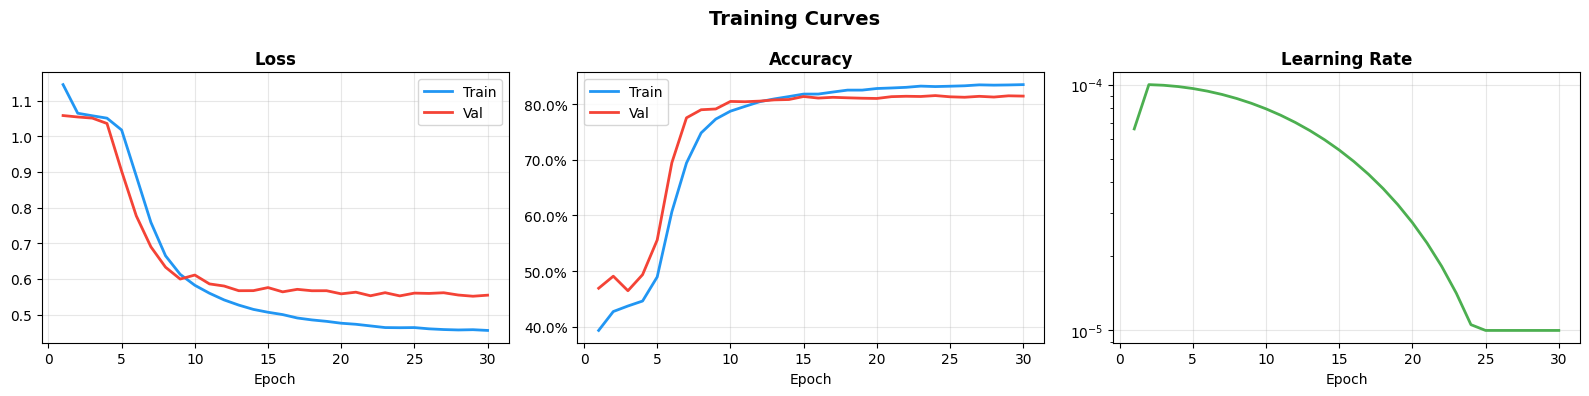

Saved → /kaggle/working/plots/training_curves.png

───────────────────────────────────────────────────────
  Val Set Results
───────────────────────────────────────────────────────
  Accuracy (overall) : 81.52%
  F1 (weighted)      : 0.8153

              precision    recall  f1-score   support

    Negative     0.7293    0.8091    0.7671     11019
     Neutral     0.8626    0.7588    0.8074     16512
    Positive     0.8320    0.8636    0.8475     20602

    accuracy                         0.8152     48133
   macro avg     0.8080    0.8105    0.8073     48133
weighted avg     0.8190    0.8152    0.8153     48133


───────────────────────────────────────────────────────
  Test Set Results
───────────────────────────────────────────────────────
  Accuracy (overall) : 80.97%
  F1 (weighted)      : 0.8100

              precision    recall  f1-score   support

    Negative     0.7144    0.8025    0.7559      5510
     Neutral     0.8567    0.7518    0.8009      8256
    Positive     0.83

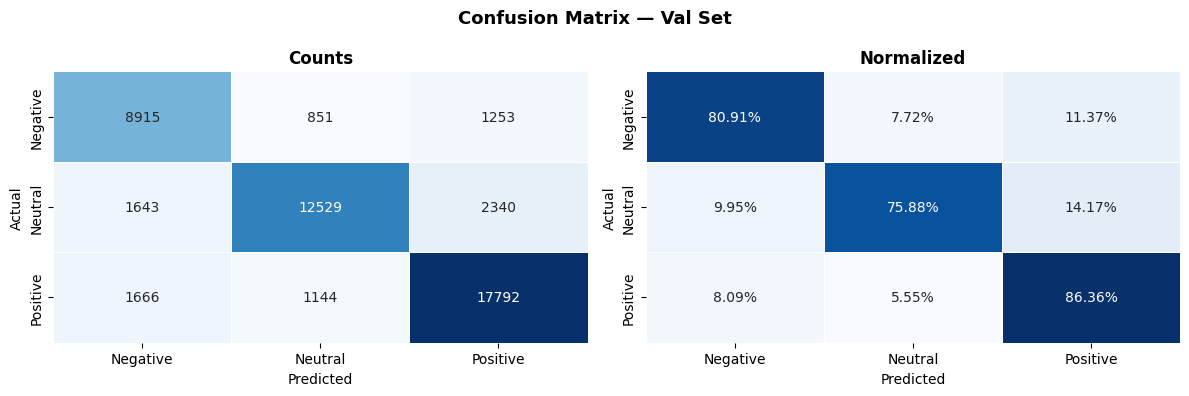

Saved → /kaggle/working/plots/cm_val.png


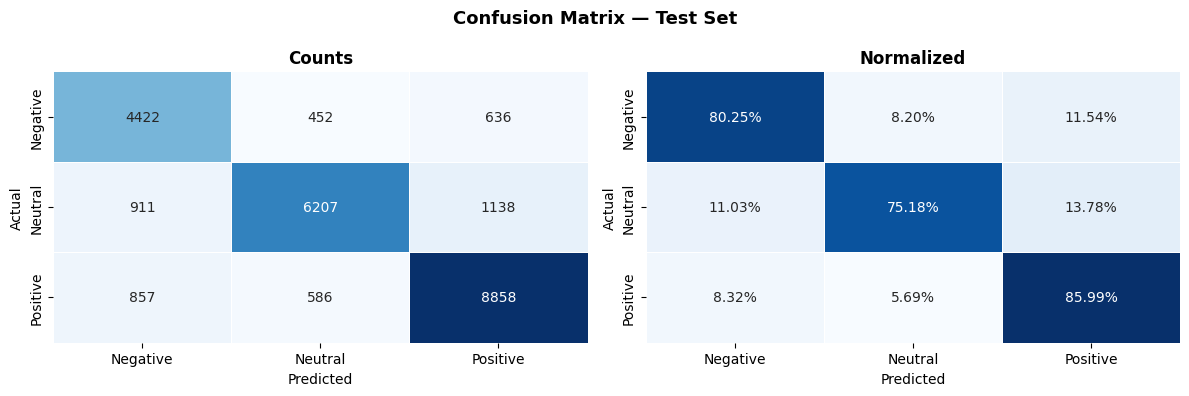

Saved → /kaggle/working/plots/cm_test.png

  ✅  PIPELINE COMPLETE!
  Test Accuracy   : 80.97%
  Test F1 (weighted): 0.8100


In [ ]:
def set_seed(seed=RANDOM_SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

# Step 1: Data 
print("=" * 65)
print("  STEP 1/4 — Loading Data & Building Vocabulary")
print("=" * 65)
train_loader, val_loader, test_loader, vocab, class_weights = make_dataloaders()

# Step 2: Model 
print("\n" + "=" * 65)
print("  STEP 2/4 — Building Model")
print("=" * 65)
model = SentimentTransformer(vocab_size=len(vocab)).to(device)
print(f"\n  Vocab size   : {len(vocab):,}")
print(f"  Embed dim    : {EMBED_DIM}  |  Heads: {NUM_HEADS}  |  Layers: {NUM_LAYERS}")
print(f"  FFN dim      : {FFN_DIM}  |  Dropout: {DROPOUT}")
print(f"  Total params : {model.count_parameters():,}")

# Step 3: Training
print("\n" + "=" * 65)
print("  STEP 3/4 — Training")
print("=" * 65)
trainer = Trainer(model, train_loader, val_loader, class_weights)
history = trainer.train()
trainer.load_best()

# Step 4: Evaluation
print("\n" + "=" * 65)
print("  STEP 4/4 — Evaluation & Visualization")
print("=" * 65)
plot_training_curves(history)

val_res  = full_evaluate(model, val_loader,  split="Val")
test_res = full_evaluate(model, test_loader, split="Test")

plot_confusion_matrix(val_res["cm"],  split="Val")
plot_confusion_matrix(test_res["cm"], split="Test")

print("\n" + "=" * 65)
print("  ✅  PIPELINE COMPLETE!")
print(f"  Test Accuracy   : {test_res['accuracy']*100:.2f}%")
print(f"  Test F1 (weighted): {test_res['f1_weighted']:.4f}")
print("=" * 65)


## 🔍 9. Inference — Dự đoán câu mới

In [19]:
@torch.no_grad()
def predict_text(text: str) -> dict:
    """Dự đoán sentiment cho một câu văn bản bất kỳ."""
    model.eval()
    ids  = vocab.encode(text, MAX_SEQ_LEN)
    mask = [1 if x != 0 else 0 for x in ids]
    input_ids = torch.tensor([ids],  dtype=torch.long).to(device)
    attn_mask = torch.tensor([mask], dtype=torch.bool).to(device)

    out   = model(input_ids, attn_mask)
    probs = F.softmax(out["logits"], dim=-1)[0].cpu()
    pred  = probs.argmax().item()

    print(f"\nText       : {text}")
    print(f"Prediction : {LABEL_NAMES[pred]}  ({probs[pred]*100:.1f}% confidence)")
    print(f"Probs      : Negative={probs[0]*100:.1f}%  "
          f"Neutral={probs[1]*100:.1f}%  "
          f"Positive={probs[2]*100:.1f}%")
    return {"label": LABEL_NAMES[pred], "probs": probs.tolist()}


# ── Test vài câu ──────────────────────────────────────────────────────────────
test_sentences = [
    "apple pay is absolutely amazing and so convenient to use",
    "i don't like the new update it crashed my phone twice",
    "the product arrived on time and packaging was okay",
    "worst customer service experience i have ever had",
    "pretty decent overall but nothing too special",
]

for sent in test_sentences:
    predict_text(sent)



Text       : apple pay is absolutely amazing and so convenient to use
Prediction : Positive  (98.0% confidence)
Probs      : Negative=0.9%  Neutral=1.1%  Positive=98.0%

Text       : i don't like the new update it crashed my phone twice
Prediction : Neutral  (35.3% confidence)
Probs      : Negative=33.9%  Neutral=35.3%  Positive=30.8%

Text       : the product arrived on time and packaging was okay
Prediction : Positive  (78.0% confidence)
Probs      : Negative=6.6%  Neutral=15.4%  Positive=78.0%

Text       : worst customer service experience i have ever had
Prediction : Negative  (98.4% confidence)
Probs      : Negative=98.4%  Neutral=1.3%  Positive=0.3%

Text       : pretty decent overall but nothing too special
Prediction : Positive  (92.5% confidence)
Probs      : Negative=2.4%  Neutral=5.1%  Positive=92.5%
